In [1]:
import sys
sys.path.append("..")

In [3]:
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

import anndata as ad
import numpy as np
import os, random, numpy as np, torch
import mgw.mgw as mgw
import scanpy as sc
import squidpy as sq
from mgw import plotting
from mgw.util import bary_proj

### Parameters for MGW

In [4]:
PCA_componet = 30
CCA_componet = 3
MSI_Top = 30

PHI_ARC = (128,256,256,128)
KNN_K= 12
DEFAULT_GW_PARAMS = dict(verbose=True, inner_maxit=3000, outer_maxit=3000, inner_tol=1e-7,   outer_tol=1e-7,   epsilon=1e-4)
DEFAULT_LR = 1e-3
DEFAULT_EPS = 1e-2
DEFAULT_ITER = 20_000

In [11]:
EXP_PATH = "../experiments/" #specify the path to save your trained phi psi model 
EXP_TAG = f'Y7_CCA{CCA_componet}_demo' #specify the name of your experiment

### Load the two dataset

In [7]:
ST_PATH= "/scratch/gpfs/BRAPHAEL/ST_SM/adata_ST_Y7_T_raw.h5ad"
MSI_PATH= "/scratch/gpfs/BRAPHAEL/ST_SM/adata_SM_Y7_T_raw.h5ad"
st = ad.read_h5ad(ST_PATH)
msi = ad.read_h5ad(MSI_PATH)

### Preprocessing spatial metabolome dataset: select metabolites with high Moran's I

In [8]:
K = MSI_Top

sc.pp.normalize_total(msi, target_sum=1e3)

sq.gr.spatial_neighbors(msi, key_added='spatial')
sq.gr.spatial_autocorr(
    msi,
    mode="moran",
    genes=None,
    layer=None,
    n_jobs=8,
)
top_moran = (
    msi.uns["moranI"]
    .sort_values("I", ascending=False)
    .head(K)
)
msi.var["highly_variable_moranI"] = msi.var_names.isin(top_moran.index)

moran_df = msi.uns["moranI"]

if "names" in moran_df.columns:          
    ranked = moran_df.sort_values("I", ascending=False)["names"].head(K)
else:
    ranked = moran_df.sort_values("I", ascending=False).index[:K]

msi.var["highly_variable_moranI"] = msi.var_names.isin(ranked)

n_total = msi.shape[1]
n_keep  = int(msi.var["highly_variable_moranI"].sum())
print(f"Before: {msi.shape}  |  marked spatially variable: {n_keep}/{n_total}")

adata_sm = msi[:, msi.var["highly_variable_moranI"]].copy()

print("After: ", msi.shape)

adata_st = st.copy()
adata_sm = msi.copy()

Before: (10649, 1299)  |  marked spatially variable: 30/1299
After:  (10649, 1299)


## 🧬 mgw_preprocess(A, B)

Prepares spatial + molecular features for alignment.

### Feature Settings
| Parameter | Description |
|----------|-------------|
| `PCA_comp` | # PCA components for expression (default: 30) |
| `CCA_comp` | # CCA components after Feeler (default: 3) |
| `use_cca_feeler` | Use small exploratory GW + CCA (to improve alignment) |
| `feeler_downsample` | Number of downsampled cells for Feeler|
| `log1p_X`, `log1p_Z` | Apply log1p to raw counts |
| `use_pca_X`, `use_pca_Z` | Use PCA or not |

### Downsampling
| Parameter | Description |
|----------|-------------|
| `max_obs_A`, `max_obs_B` | Limit number of cells for speed (None = no limit) |

### Feeler Variants
| Parameter | Description |
|----------|-------------|
| `spatial_only` | Feeler uses only spatial information |
| `feature_only` | Feeler uses only gene expression |
> If both `False`, Feeler uses spatial + feature together.

### Other
| Parameter | Description |
|----------|-------------|
| `verbose` | Print logs |


In [9]:
pre = mgw.mgw_preprocess(
    st, msi,
    PCA_comp=PCA_componet,
    CCA_comp=CCA_componet,
    use_cca_feeler=True, 
    use_pca_X=True,
    use_pca_Z=False, #False if the features from second modality are intensities which doesn't make sense to run pca on
    log1p_X=True,
    log1p_Z=False,#False if the features from second modality are not counts which doesn't make sense to run log1p on
    verbose=True
)

[mgw.pre] PCA/raw shapes: X=(2018, 30)  Z=(10649, 1299)
[mgw.pre] CCA feeler: PCA → small GW (fused) → barycentric → CCA
Using precomputed PCA (30 comps).
Computing PCA (30 comps)...
Feature shapes -> X: (2018, 30) Z: (10649, 30)
Feeler GW sizes: X-side 2018, Z-side 8000
Solving feeler feature alignment.
Computing CCA Components
CCA dims: 3  (applied to full sets)


## 🚀 mgw_align_core(pre)

Trains neural fields φ, ψ → estimates geodesics → solves GW.

### Neural Network
| Parameter | Description |
|----------|-------------|
| `widths` | Hidden layer sizes (default: (128,256,256,128)) |
| `lr` | Learning rate |
| `niter` | Number of training steps |
| `print_every` | Frequency of log printing |

### Geometry & Graph
| Parameter | Description |
|----------|-------------|
| `knn_k` | KNN graph size for geodesics (default: 12) |
| `geodesic_eps` | Finite-difference epsilon for metric |

### GW Solver
| Parameter | Description |
|----------|-------------|
| `gw_params` | Dict of GW optimization settings (`epsilon`, tolerances, iterations) |

### Compute & Saving
| Parameter | Description |
|----------|-------------|
| `device` | `'cuda'` or `'cpu'` |
| `torch_default_dtype` | Use `torch.float64` for high precision |
| `save_dir` | Save neural fields + GW coupling |
| `tag` | Append suffix to saved filenames |

### Other
| Parameter | Description |
|----------|-------------|
| `plot_net` | Plot neural prediction vs. true PCA/CCA |
| `use_cca` | Use CCA components for training or use PCA components for training | 
| `verbose` | Print logs |


[mgw.core] device=cuda dtype=torch.float64
[mgw.core] dims: E=2, F_M=3, F_N=3
[mgw.core] training φ, ψ
[train_phi] step=1000 loss=0.058989
[train_phi] step=2000 loss=0.047498
[train_phi] step=3000 loss=0.042961
[train_phi] step=4000 loss=0.040540
[train_phi] step=5000 loss=0.038542
[train_phi] step=6000 loss=0.036795
[train_phi] step=7000 loss=0.037749
[train_phi] step=8000 loss=0.034479
[train_phi] step=9000 loss=0.033432
[train_phi] step=10000 loss=0.032153
[train_phi] step=11000 loss=0.031043
[train_phi] step=12000 loss=0.031372
[train_phi] step=13000 loss=0.029359
[train_phi] step=14000 loss=0.029247
[train_phi] step=15000 loss=0.027404
[train_phi] step=16000 loss=0.026488
[train_phi] step=17000 loss=0.025933
[train_phi] step=18000 loss=0.024986
[train_phi] step=19000 loss=0.033929
[train_phi] step=20000 loss=0.023262
[train_phi] step=1000 loss=0.208489
[train_phi] step=2000 loss=0.201953
[train_phi] step=3000 loss=0.199481
[train_phi] step=4000 loss=0.210691
[train_phi] step=5000 

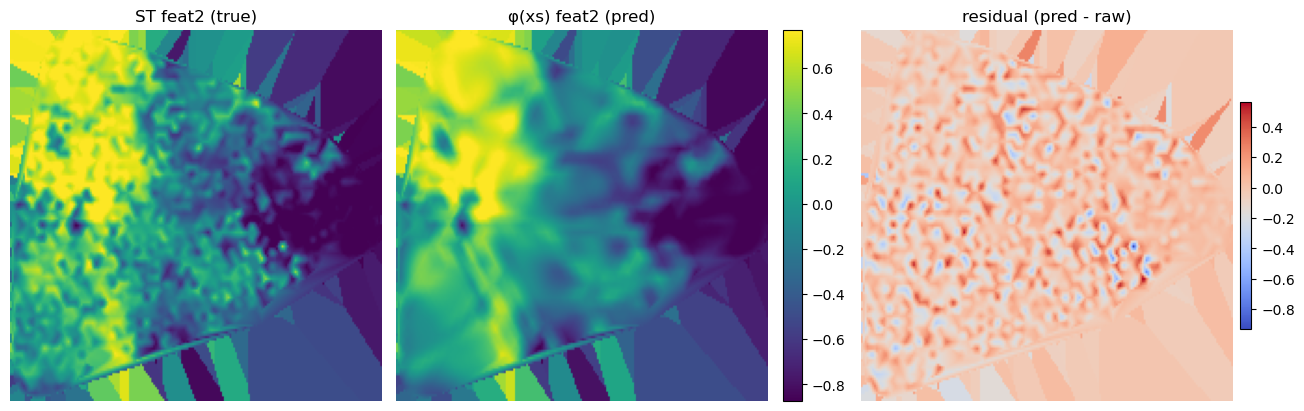

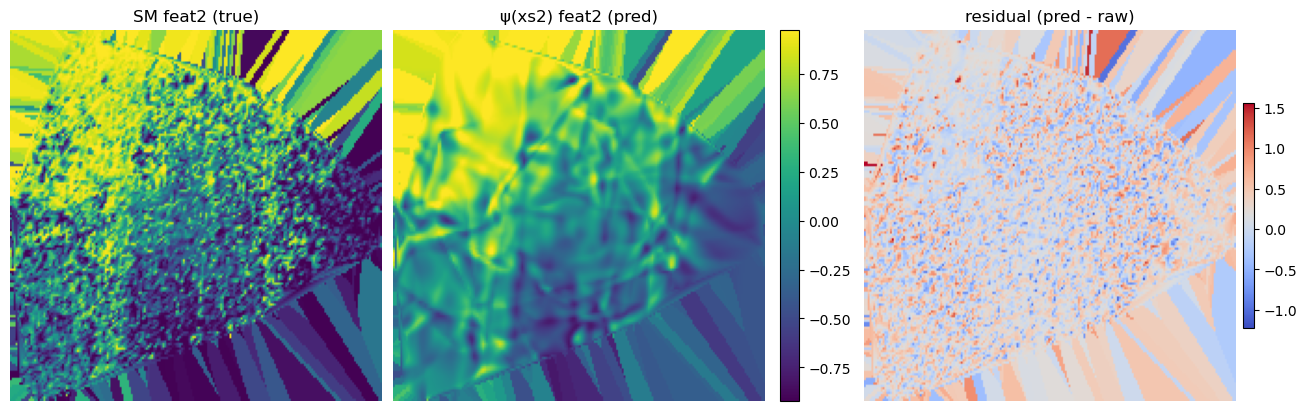

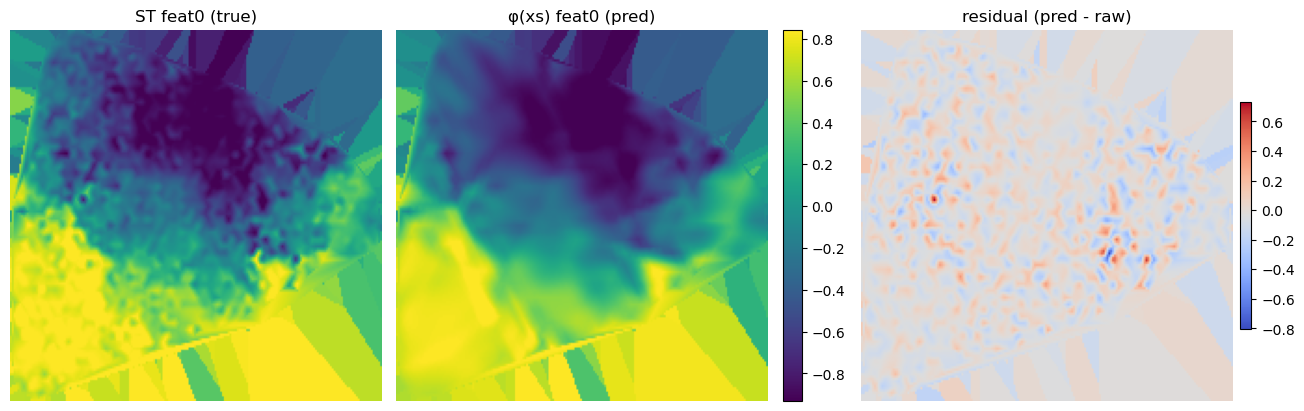

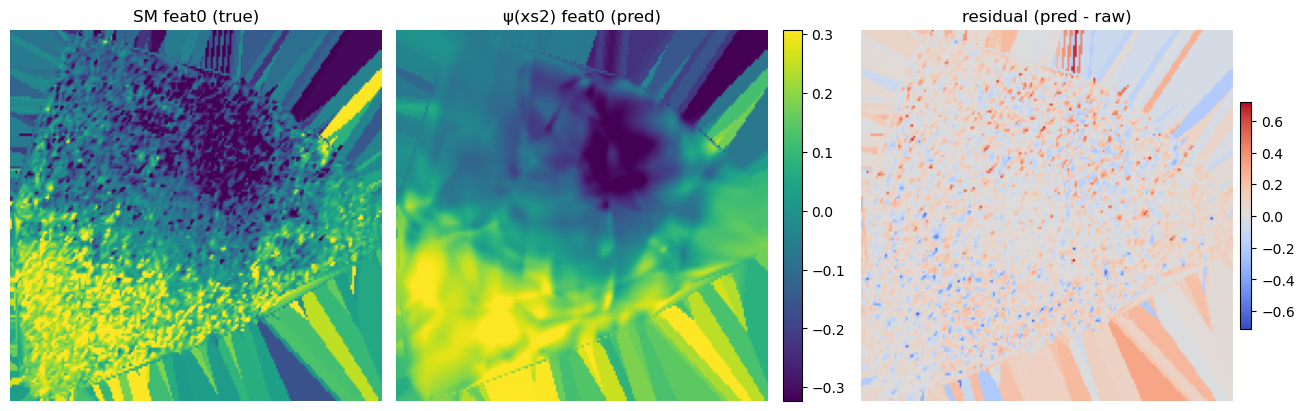

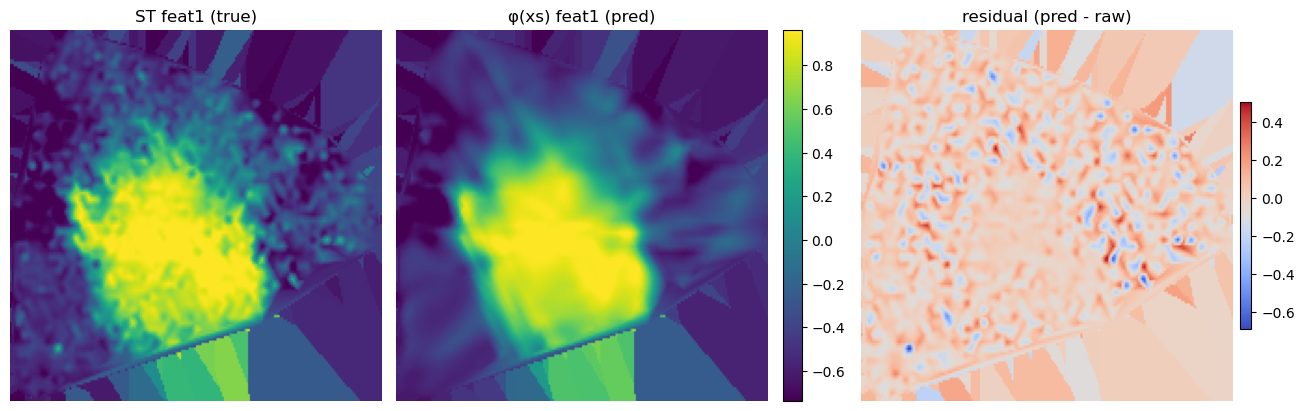

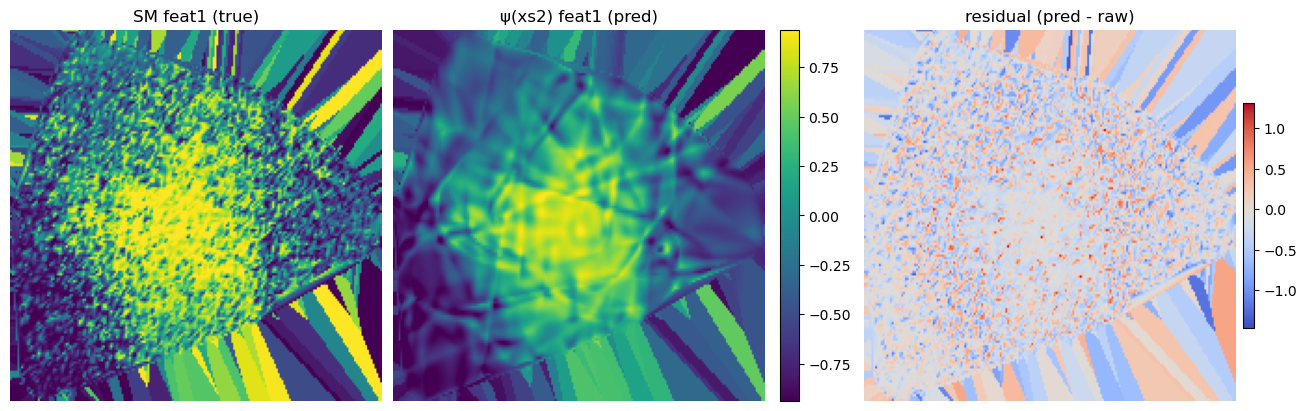

[mgw.core] pullback metrics & geodesics
Rescaling Jacobians by 66.7600331928324.
Rescaling Jacobians by 300.84825503629474.
[mgw.core] solving GW with {'verbose': True, 'inner_maxit': 3000, 'outer_maxit': 3000, 'inner_tol': 1e-07, 'outer_tol': 1e-07, 'epsilon': 0.0001}
[mgw.core] coupling: shape=(2018, 10649), mass=1.000010


In [12]:
out = mgw.mgw_align_core(
        pre,
        widths=PHI_ARC,
        lr=DEFAULT_LR,
        niter=DEFAULT_ITER,
        knn_k=KNN_K,
        geodesic_eps=DEFAULT_EPS,
        save_dir=EXP_PATH, 
        tag=EXP_TAG, 
        verbose=True,
        plot_net=True, # zoom in to visually check if the two modalities shown similar pattern
        gw_params = DEFAULT_GW_PARAMS
    )

### Plotting the coupling matrix 

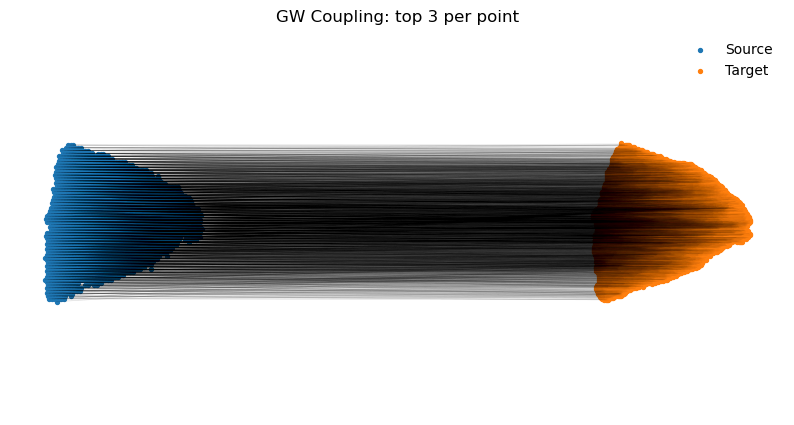

In [13]:
xs = out["xs"]
xs2 = out["xs2"]
P = out["P"]
xs_aligned, xt_aligned, R, tvec = plotting.procrustes_from_coupling(xs, xs2, P)
plotting.plot_alignment_lines_dense(xs_aligned, xt_aligned, P, alpha=0.05)

### Use the coupling matrix P to perform Barycentric projection from one modality to another modality

In [14]:
#RAW ST dataset
st

AnnData object with n_obs × n_vars = 2018 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [15]:
#RAW SM dataset
msi

AnnData object with n_obs × n_vars = 10649 × 1299
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index', 'total_intensity', 'mean_intensity'
    var: 'name', 'type', 'highly_variable_moranI'
    uns: 'spatial', 'spatial_neighbors', 'moranI'
    obsm: 'spatial', 'spatial_normalized', 'spatial_transformed', 'spatial_transformed_scaled'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [16]:
# USE ST coordinates as base
adata_sm2st = bary_proj(st, msi, P)
adata_sm2st

AnnData object with n_obs × n_vars = 2018 × 37900
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome', 'type', 'name', 'highly_variable_moranI'
    uns: 'spatial', 'joint_base', 'features'
    obsm: 'spatial', 'coupling_to_SM'

In [17]:
# USE SM coordinates as base
adata_st2sm = bary_proj(msi, st, P.T)
adata_st2sm

AnnData object with n_obs × n_vars = 10649 × 37900
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index', 'total_intensity', 'mean_intensity'
    var: 'name', 'type', 'highly_variable_moranI', 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatial_neighbors', 'moranI', 'joint_base', 'features'
    obsm: 'spatial', 'spatial_normalized', 'spatial_transformed', 'spatial_transformed_scaled', 'coupling_to_SM'
    obsp: 'spatial_connectivities', 'spatial_distances'